# Baseline German

### Purpose:

Evaluate the pretrained TrOCR model (trained primarily on English text) on German word images containing special characters (ä, ö, ü, ß).

### Why this baseline matters?

This baseline is to show the vocabulary difference between the pretrained model and German text, to show why fine-tuning is needed.

### Inputs:
 - Synthetic German word images
 - Corresponding ground-truth labels

### Outputs:
 - Baseline German CER/WER (expected to be significantly worse than English)

In [8]:
import os
import json
import random
import numpy as np
import time
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import display
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from jiwer import cer, wer

In [2]:
Base_dir = ".."
Dataset_dir = os.path.join(Base_dir, "Datasets")

font_path = os.path.join(Dataset_dir, "fonts", "DejaVuSans.ttf")
assert os.path.exists(font_path), font_path

German_json = os.path.join(Dataset_dir, "German-words-5000-words.json")
German_Synth_dir = os.path.join(Dataset_dir, "german_synth")
os.makedirs(German_Synth_dir, exist_ok=True)

print(German_json)

../Datasets/German-words-5000-words.json


In [3]:
## Load json
with open(German_json, "r", encoding="utf-8") as f:
    german_data = json.load(f)
if isinstance(german_data, list):
    german_words = german_data
elif "words" in german_data:
    german_words = german_data["words"]
else:
    german_words = list(german_data.values())

len(german_words), german_words[:10]

(4999,
 ['Abbaumaschinen',
  'Abbauorte',
  'Abbausituationen',
  'Abendwache',
  'Abfallens',
  'Abfalltasche',
  'Abfallvermeidungen',
  'Abfallvolumen',
  'Abfertigungsbeamten',
  'Abfertigungsfeld'])

## Create Synthetic Distorted Images

In [4]:
IMG_W, IMG_H = 260, 100

def get_font(size=32):
    return ImageFont.truetype(font_path, size=size)

def make_german_image(word: str, idx: int) -> str:
    """Generate a synthetic OCR image for a single German word.

    Pipeline:
        1. Render the word onto a white background.
        2. Dynamically shrink the font so the word fits within the canvas.
        3. Apply small geometric augmentation (rotation + random).
        4. Apply photometric augmentation (blur + Gaussian noise).
        5. Save the image.

    Why:
        Synthetic data enables coverage of German-specific
        characters (ä, ö, ü, ß), which are not handled well by the
        pretrained English OCR model.

    Args:
        word: Ground-truth German word to render.
        idx: Unique index used to generate a deterministic filename.

    Returns:
        Path to the saved synthetic image file.
    """

    # Create blank white canvas
    img = Image.new("RGB", (IMG_W, IMG_H), "white")
    draw = ImageDraw.Draw(img)
    font_size = 32
    margin = 8
    while True:
        font = get_font(size=font_size)
        bbox = draw.textbbox((0, 0), word, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]

        # Stop shrinking once the word fits or a minimum font size is reached
        if w <= IMG_W - 2 * margin or font_size <= 10:
            break
        font_size -= 2 
        
    # Center the text within the image to reduce positional bias
    x = (IMG_W - w) // 2
    y = (IMG_H - h) // 2
    draw.text((x, y), word, font=font, fill="black")

    # adding some slight rotation and noise
    angle = random.uniform(-10, 10)
    img = img.rotate(angle, expand=True, fillcolor="white")

    canvas = Image.new("RGB", (IMG_W + 10, IMG_H + 10), "white")
    off_x = random.randint(0, 10)
    off_y = random.randint(0, 10)
    canvas.paste(img, (off_x, off_y))
    img = canvas.resize((IMG_W, IMG_H))

    # adding random blur
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.2)))

    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 8, arr.shape)  # sigma=8
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr)

    filename = f"de_{idx:05d}.png"
    out_path = os.path.join(German_Synth_dir, filename)  # use your variable name here
    img.save(out_path)
    return out_path

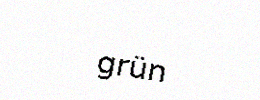

In [5]:
path = make_german_image("grün", 0)
display(Image.open(path))

In [6]:
## Generate synthetic data

max_words = len(german_words)    
records = []

for i, word in enumerate(german_words[:max_words]):
    img_path = make_german_image(word, i)
    records.append({"image_path": img_path, "label": word})

len(records)

4999

## Baseline_German

In [9]:
test_frac = 0.2


german_df = pd.DataFrame(records)
german_test_df = german_df.sample(frac=test_frac, random_state=42)
german_train_df = german_df.drop(german_test_df.index)

german_train_df = german_train_df.reset_index(drop=True)
german_test_df = german_test_df.reset_index(drop=True)

len(german_train_df), len(german_test_df)

(3999, 1000)

In [18]:
annot_dir = os.path.join(Dataset_dir, "Annotated_files")  
os.makedirs(annot_dir, exist_ok=True)

german_train_path = os.path.join(annot_dir, "german_train_annotations.json")
german_test_path  = os.path.join(annot_dir, "german_test_annotations.json")

german_train_df.to_json(german_train_path, orient="records", force_ascii=False, indent=2)
german_test_df.to_json(german_test_path, orient="records", force_ascii=False, indent=2)

print("Saved:", german_train_path)
print("Saved:", german_test_path)

Saved: ../Datasets/Annotated_files/german_train_annotations.json
Saved: ../Datasets/Annotated_files/german_test_annotations.json


Diplomexamens ../Datasets/german_synth/de_00670.png


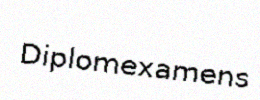

In [11]:
row = german_test_df.sample(1, random_state=100).iloc[0]
print(row["label"], row["image_path"])
display(Image.open(row["image_path"]))

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [13]:
model_name = "microsoft/trocr-base-printed"

processor = TrOCRProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [14]:
def predict_word_from_path(path: str) -> str:
    image = Image.open(path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pixel_values)
    return processor.batch_decode(ids, skip_special_tokens=True)[0]


GT: Punktbrücke
Pred: PUNKTBR�CKE


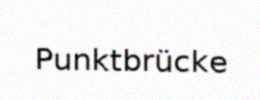

In [15]:
## Sanity check
sample = german_test_df.sample(1, random_state=440).iloc[0]
print("GT:", sample["label"])
print("Pred:", predict_word_from_path(sample["image_path"]))
display(Image.open(sample["image_path"]))


### Evaluation

In [16]:
def evaluate_baseline(df, max_samples=500):
    refs, hyps = [], []
    t0 = time.time()

    sub_df = df.sample(min(max_samples, len(df)), random_state=42).reset_index(drop=True)

    for i, row in sub_df.iterrows():
        gt = row["label"]
        pred = predict_word_from_path(row["image_path"])

        refs.append(gt)
        hyps.append(pred)

        if (i + 1) % 50 == 0:
            print(f"{i+1}/{len(sub_df)} done")

    char_err = cer(refs, hyps)
    word_err = wer(refs, hyps)
    word_acc = 1 - word_err
    elapsed = time.time() - t0

    return {
        "num_samples": len(sub_df),
        "cer": char_err,
        "word_error_rate": word_err,
        "word_accuracy": word_acc,
        "time_seconds": elapsed,
    }, refs, hyps


In [17]:
german_baseline_metrics, de_refs, de_hyps = evaluate_baseline(german_test_df, max_samples=300)
german_baseline_metrics

50/300 done
100/300 done
150/300 done
200/300 done
250/300 done
300/300 done


{'num_samples': 300,
 'cer': 0.9517612743998205,
 'word_error_rate': 1.0,
 'word_accuracy': 0.0,
 'time_seconds': 52.7695415019989}